<style>
    body, p, h1, h2, h3, li, span, div {
        font-family: 'Times New Roman', Times, serif !important;
    }
    ul ul, li li {
        list-style-type: none !important;
    }
    ul ul li::before, li li::before {
        content: "- " !important;
        display: inline-block;
        width: 1.2em;
        margin-left: -1.2em;
    }
    pre, code, .jp-OutputArea-output {
        font-family: Consolas, "Courier New", monospace !important;
    }
</style>

<br>

<div style="text-align: center;">
    <span style="font-size: 24px;">Examen Primer Parcial ML2</span><br><br>
    <span>Septiembre 30, 2026</span><br><br><br>
    <img src="img/logoitqv1.jpg" width="450">
</div>

<div style="text-align: center;">
    <img src="img/python_logo.png" width="500">
</div>

*Christian Villegas*

Link del repositorio: https://github.com/christian7villegas/Introducci-nPythona

In [2]:
import os
import numpy as np
import pandas as pd
from math import sqrt
from pprint import pprint
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn import preprocessing
from sklearn.metrics import make_scorer, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SelectKBest, f_regression

In [5]:
# Autentica y descarga el dataset automáticamente
os.environ['KAGGLE_API_TOKEN'] = "KGAT_8b945e7317edc35d87d79a529a9e565c"
kaggle.api.dataset_download_files('mirichoi0218/insurance', path='.', unzip=True)

# Carga y revisa la estructura básica
datos = pd.read_csv('insurance.csv')
datos.info()
datos.head()

Dataset URL: https://www.kaggle.com/datasets/mirichoi0218/insurance
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


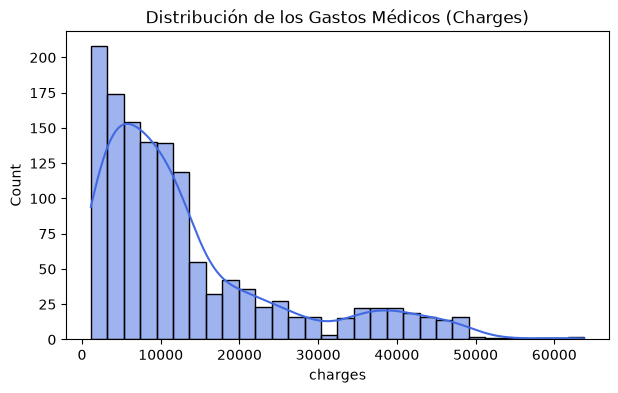

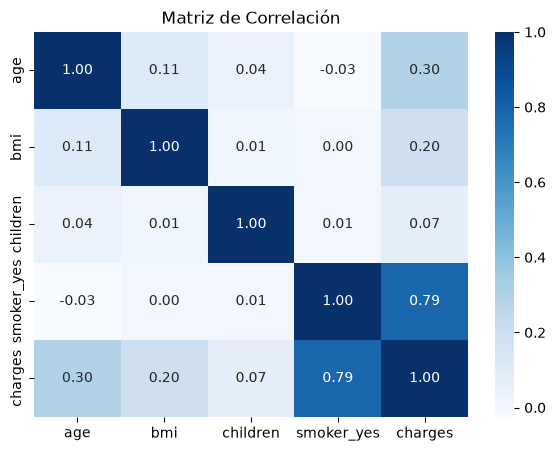

In [33]:
# EDA y calidad de los datos 

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Distribución de la variable objetivo (Gastos médicos)
plt.figure(figsize=(7, 4))
sns.histplot(datos['charges'], kde=True, bins=30, color='royalblue')
plt.title('Distribución de los Gastos Médicos (Charges)')
plt.show()

# 2. Matriz de correlación para ver qué variables numéricas afectan más a los gastos
columnas_deseadas = ['age', 'bmi', 'children', 'smoker_yes', 'charges']
datos_filtrados = datos_preparados[columnas_deseadas]

plt.figure(figsize=(7, 5))
sns.heatmap(datos_filtrados.corr(), annot=True, cmap='Blues', fmt=".2f")
plt.title('Matriz de Correlación')
plt.show()

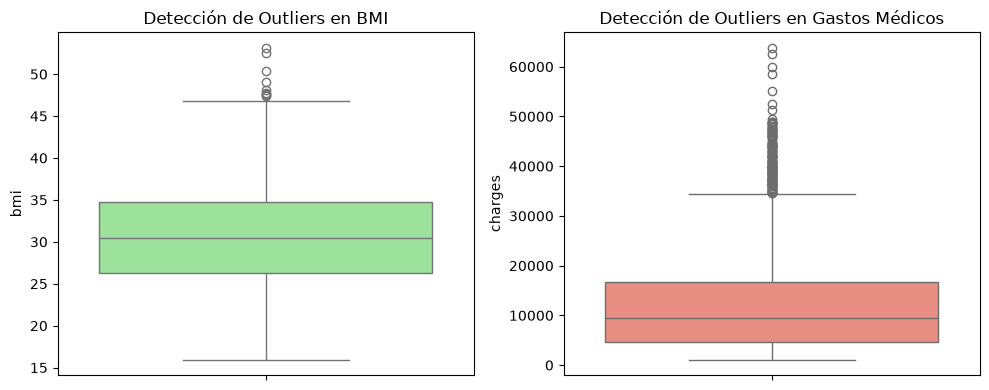

In [23]:
# Detección de outliers

# Genera Boxplots para detectar valores atípicos visualmente
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.boxplot(ax=axes[0], data=datos, y='bmi', color='lightgreen')
axes[0].set_title('Detección de Outliers en BMI')

sns.boxplot(ax=axes[1], data=datos, y='charges', color='salmon')
axes[1].set_title('Detección de Outliers en Gastos Médicos')

plt.tight_layout()
plt.show()

In [30]:
# Preparación de variables

# Utiliza pd.get_dummies para convertir las variables de texto en numéricas
# drop_first=True evita el problema de multicolinealidad eliminando una de las columnas redundantes
datos_preparados = pd.get_dummies(datos, columns=['sex', 'smoker', 'region'], drop_first=True)

# Se visualiza cómo quedó el dataset después de la transformación
print("--- DATASET DESPUÉS DE LA PREPARACIÓN DE VARIABLES ---")
display(datos_preparados.head())

# Definición de X (Atributos) e y (Variable Objetivo)
# Separa las características (X) y lo que queremos predecir (y)
X = datos_preparados.drop('charges', axis=1)
y = datos_preparados['charges']

print(f"\nDimensiones de X (Atributos): {X.shape}")
print(f"Dimensiones de y (Objetivo): {y.shape}")

--- DATASET DESPUÉS DE LA PREPARACIÓN DE VARIABLES ---


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False



Dimensiones de X (Atributos): (1338, 8)
Dimensiones de y (Objetivo): (1338,)


In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression

# Validación de datos - Partición externa

# Se dividen los datos: 80% para entrenar y 20% para probar/validar 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamaño de entrenamiento: {X_train.shape}")
print(f"Tamaño de validación (test): {X_test.shape}")


# Normalización o estandarización 

# Se estandarizan los datos para que todos tengan la misma escala 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Transformamos el test usando el patrón del train

# Selección de atributos 

# Se seleccionan las 5 mejores características que explican los gastos médicos
selector = SelectKBest(score_func=f_regression, k=5)
X_train_final = selector.fit_transform(X_train_scaled, y_train)
X_test_final = selector.transform(X_test_scaled)

# Mostrar cuáles fueron los atributos ganadores
columnas_seleccionadas = X.columns[selector.get_support()]
print("\nAtributos seleccionados por el modelo:")
print(list(columnas_seleccionadas))

Tamaño de entrenamiento: (1070, 8)
Tamaño de validación (test): (268, 8)

Atributos seleccionados por el modelo:
['age', 'bmi', 'children', 'smoker_yes', 'region_southeast']


Coeficientes del modelo: 
 [3611.81511213 2006.17292632  516.7966926  9564.87978944 -110.03263925]

Término independiente:  13346.089736364485

MÉTRICAS DE EVALUACIÓN:
MAE: 4200.4893
MSE: 33820228.1391
RMSE: 5815.5162
MAPE: 47.5938
R2: 0.7822


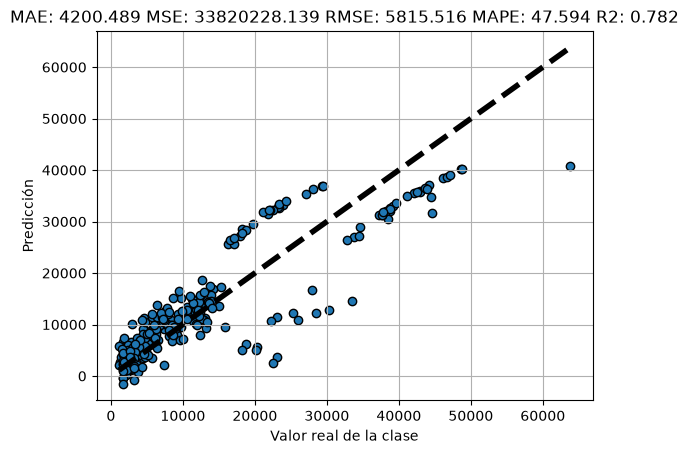


Predicción para el nuevo paciente: $30789.47


In [32]:
# Entrenamiento mediante Regresión Lineal

# Construcción del algoritmo de aprendizaje (Paso 5 del docente)
modelo = LinearRegression(fit_intercept=True)

# Entrenamiento con los datos preparados
modelo.fit(X_train_final, y_train)

print('Coeficientes del modelo: \n', modelo.coef_)
print('\nTérmino independiente: ', modelo.intercept_)

# Evaluación 

# Predicción del conjunto de test (Paso 9 del docente)
y_pred_test = modelo.predict(X_test_final)

# Cálculo de las métricas de evaluación
MAE = metrics.mean_absolute_error(y_test, y_pred_test)
MSE = metrics.mean_squared_error(y_test, y_pred_test) # En versiones recientes no requiere squared=True
RMSE = np.sqrt(MSE) # Raíz del error cuadrático medio
MAPE = metrics.mean_absolute_percentage_error(y_test, y_pred_test) * 100
R2 = metrics.r2_score(y_test, y_pred_test)

print('\nMÉTRICAS DE EVALUACIÓN:')
print('MAE: %.4f' % MAE)
print('MSE: %.4f' % MSE)
print('RMSE: %.4f' % RMSE)
print('MAPE: %.4f' % MAPE)
print('R2: %.4f' % R2)

# Gráfica de realidad vs. predicción (Estilo exacto del docente)
fig, ax = plt.subplots()
ax.scatter(y_test, y_pred_test, edgecolors=(0,0,0))
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=4)
ax.set_xlabel('Valor real de la clase')
ax.set_ylabel('Predicción')
plt.title("MAE: %.3f MSE: %.3f RMSE: %.3f MAPE: %.3f R2: %.3f" % (MAE, MSE, RMSE, MAPE, R2))
plt.grid()
plt.show()

# Predicción con nuevos datos 

# Creamos un paciente nuevo ficticio copiando la estructura de las columnas originales de X
nuevo_paciente = pd.DataFrame([[35, 28.5, 2, 0, 1, 0, 0, 0]], columns=X.columns)

# Aplicamos las mismas transformaciones (estandarización y selección) al nuevo dato
nuevo_paciente_scaled = scaler.transform(nuevo_paciente)
nuevo_paciente_final = selector.transform(nuevo_paciente_scaled)

# Generamos la estimación de sus gastos médicos
estimacion = modelo.predict(nuevo_paciente_final)
print(f"\nPredicción para el nuevo paciente: ${estimacion[0]:.2f}")